<a href="https://colab.research.google.com/github/ragulsulochana/Ragul-codeboosters-2026/blob/main/DAY%202/day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("all libraries imported successfully")
print (f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.sqlite_version}")

all libraries imported successfully
pandas version:2.2.2
sqlite3 version:3.37.2


In [4]:
import os
import pandas as pd

file_path = "/content/student_performance.csv"

# Check if the file exists. If not, create a dummy file for demonstration.
if not os.path.exists(file_path):
    print(f"Warning: '{file_path}' not found. Creating a dummy dataset for demonstration.")
    dummy_data = """student_id,name,department,math_score,science_score,programming_score,attendance_percentage
1,Alice,Computer Science,90,85,92,95
2,Bob,Mathematics,78,82,75,88
3,Charlie,Physics,65,70,68,75
4,David,Computer Science,88,90,85,93
5,Eve,Mathematics,72,75,70,80
6,Frank,Computer Science,95,91,96,98
7,Grace,Physics,70,68,72,82
8,Heidi,Mathematics,80,83,79,90
9,Ivan,Computer Science,82,88,80,91
10,Judy,Physics,60,65,62,70
"""
    with open(file_path, "w") as f:
        f.write(dummy_data)
    print(f"Dummy dataset created at {file_path}.")

df = pd.read_csv(file_path)
print(f"Dataset Loaded: {df.shape}")
print("Columns: ",df.columns.tolist())
print("\nFirst Three rows:")
df.head(3)

Dummy dataset created at /content/student_performance.csv.
Dataset Loaded: (10, 7)
Columns:  ['student_id', 'name', 'department', 'math_score', 'science_score', 'programming_score', 'attendance_percentage']

First Three rows:


,student_id,name,department,math_score,science_score,programming_score,attendance_percentage
0,1,Alice,Computer Science,90,85,92,95
1,2,Bob,Mathematics,78,82,75,88
2,3,Charlie,Physics,65,70,68,75


In [5]:
conn = sqlite3.connect('college.db')

cursor = conn.cursor()
print("Database created and Successfully Connected to SQLite")

Database created and Successfully Connected to SQLite


In [6]:
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

cursor.execute("SELECT COUNT(*) FROM students;")
count = cursor.fetchone()[0]
print(f"Number of rows in the 'students' table: {count}")

Number of rows in the 'students' table: 10


In [7]:
def run_query(query, description):
  print(description)
  result = pd.read_sql_query(query, conn)
  return result

In [8]:
query1 = """
  SELECT student_id, name, department, math_score, attendance_percentage
  FROM students
  LIMIT 10
"""

result1 = run_query(query1, "Query 1: First 10 Students (SELECT + LIMIT)")
result1

Query 1: First 10 Students (SELECT + LIMIT)


,student_id,name,department,math_score,attendance_percentage
0,1,Alice,Computer Science,90,95
1,2,Bob,Mathematics,78,88
2,3,Charlie,Physics,65,75
3,4,David,Computer Science,88,93
4,5,Eve,Mathematics,72,80
5,6,Frank,Computer Science,95,98
6,7,Grace,Physics,70,82
7,8,Heidi,Mathematics,80,90
8,9,Ivan,Computer Science,82,91
9,10,Judy,Physics,60,70


In [10]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()

query = "SELECT student_id , name , department FROM students LIMIT 10"
data = pd.read_sql(query,conn)
print("=== DataBase Connected Successfully ===")
print(data)
conn.close()

=== DataBase Connected Successfully ===
   student_id     name        department
0           1    Alice  Computer Science
1           2      Bob       Mathematics
2           3  Charlie           Physics
3           4    David  Computer Science
4           5      Eve       Mathematics
5           6    Frank  Computer Science
6           7    Grace           Physics
7           8    Heidi       Mathematics
8           9     Ivan  Computer Science
9          10     Judy           Physics


In [11]:
conn = sqlite3.connect('college.db')
query = "SELECT name, department, math_score FROM students ORDER BY math_score DESC LIMIT 5"
data_top_5 = pd.read_sql(query, conn)
print("=== Top 5 Students by Math Score ===")
print(data_top_5)
conn.close()

=== Top 5 Students by Math Score ===
    name        department  math_score
0  Frank  Computer Science          95
1  Alice  Computer Science          90
2  David  Computer Science          88
3   Ivan  Computer Science          82
4  Heidi       Mathematics          80


In [12]:
conn = sqlite3.connect('college.db')
query = "SELECT name, department, math_score, science_score, programming_score, attendance_percentage FROM students WHERE department = 'Computer Science'"
data = pd.read_sql(query, conn)
print("=== DataBase Connected Successfully ===")
print(data)
conn.close()

=== DataBase Connected Successfully ===
    name        department  math_score  science_score  programming_score  \
0  Alice  Computer Science          90             85                 92   
1  David  Computer Science          88             90                 85   
2  Frank  Computer Science          95             91                 96   
3   Ivan  Computer Science          82             88                 80   

   attendance_percentage  
0                     95  
1                     93  
2                     98  
3                     91  


In [14]:
import sqlite3

# Establish connection for this query
conn = sqlite3.connect('college.db')

query5 = """
  SELECT name, department, attendance_percentage
  FROM students
  WHERE attendance_percentage > 90 AND department != 'Civil'
  ORDER BY attendance_percentage DESC
"""

result5 = run_query(query5, "Query 5: High Attendance (>90%) Excluding Civil")

# Close the connection after the query is executed
conn.close()

result5

Query 5: High Attendance (>90%) Excluding Civil


,name,department,attendance_percentage
0,Frank,Computer Science,98
1,Alice,Computer Science,95
2,David,Computer Science,93
3,Ivan,Computer Science,91


In [15]:
import sqlite3

conn = sqlite3.connect('college.db')
query5 = """
  SELECT name, department, attendance_percentage
  FROM students
  WHERE attendance_percentage > 93 AND department != 'Mechanical'
  ORDER BY attendance_percentage DESC
"""

result5 = run_query(query5, "Query 5: High Attendance (>93%) Excluding Mechanical")
conn.close()
result5

Query 5: High Attendance (>93%) Excluding Mechanical


,name,department,attendance_percentage
0,Frank,Computer Science,98
1,Alice,Computer Science,95


In [16]:
import sqlite3

conn = sqlite3.connect('college.db')
query = """
  SELECT name
  FROM students
  WHERE name BETWEEN 'A' AND 'F'
  ORDER BY name
"""

result = run_query(query, "Query: Names starting with A-F using BETWEEN")
conn.close()
print(result)

Query: Names starting with A-F using BETWEEN
      name
0    Alice
1      Bob
2  Charlie
3    David
4      Eve


In [17]:
import sqlite3

conn = sqlite3.connect('college.db')
query6  = """
  SELECT department,
  COUNT(*) AS student_count,
  ROUND(AVG(math_score), 2) AS average_math_score,
  ROUND(AVG(science_score), 2) AS average_science_score,
  ROUND(AVG(programming_score), 2) AS average_programming_score,
  ROUND(AVG(attendance_percentage), 2) AS average_attendance_percentage
  FROM students
  GROUP BY department
  ORDER BY average_math_score DESC
"""

result6 = run_query(query6, "Query 5")
conn.close()
result6

Query 5


,department,student_count,average_math_score,average_science_score,average_programming_score,average_attendance_percentage
0,Computer Science,4,88.75,88.50,88.25,94.25
1,Mathematics,3,76.67,80.00,74.67,86.00
2,Physics,3,65.00,67.67,67.33,75.67


In [18]:
import sqlite3

conn = sqlite3.connect('college.db')
query7 = """
  SELECT department,
  ROUND(AVG(math_score), 2) AS average_math_score,
  COUNT(*) AS students_c
  FROM students
  WHERE department != 'Civil'
  GROUP BY department
"""

result7 = run_query(query7, "Query 7")
conn.close()
result7

Query 7


,department,average_math_score,students_c
0,Computer Science,88.75,4
1,Mathematics,76.67,3
2,Physics,65.00,3


In [24]:
import sqlite3
conn = sqlite3.connect('college.db')
cursor = conn.cursor()
chart_sql = """
SELECT department , ROUND(AVG(math_score)) AS  avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
data = pd.read_sql(chart_sql,conn)
conn.close()
print("=== DataBase Connected Successfully ===")
print("")
print(data)
conn.close()

=== DataBase Connected Successfully ===

         department  avg_math
0  Computer Science      89.0
1       Mathematics      77.0
2           Physics      65.0


In [23]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('college.db')

chart_sql = """
SELECT department , ROUND(AVG(math_score)) AS  avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
data = pd.read_sql(chart_sql,conn)
conn.close()
print("=== DataBase Connected Successfully ===")
print("")
print(data)

=== DataBase Connected Successfully ===

         department  avg_math
0  Computer Science      89.0
1       Mathematics      77.0
2           Physics      65.0


=== Aggregated Data for Plotting ===
         department  avg_math
0  Computer Science      89.0
1       Mathematics      77.0
2           Physics      65.0


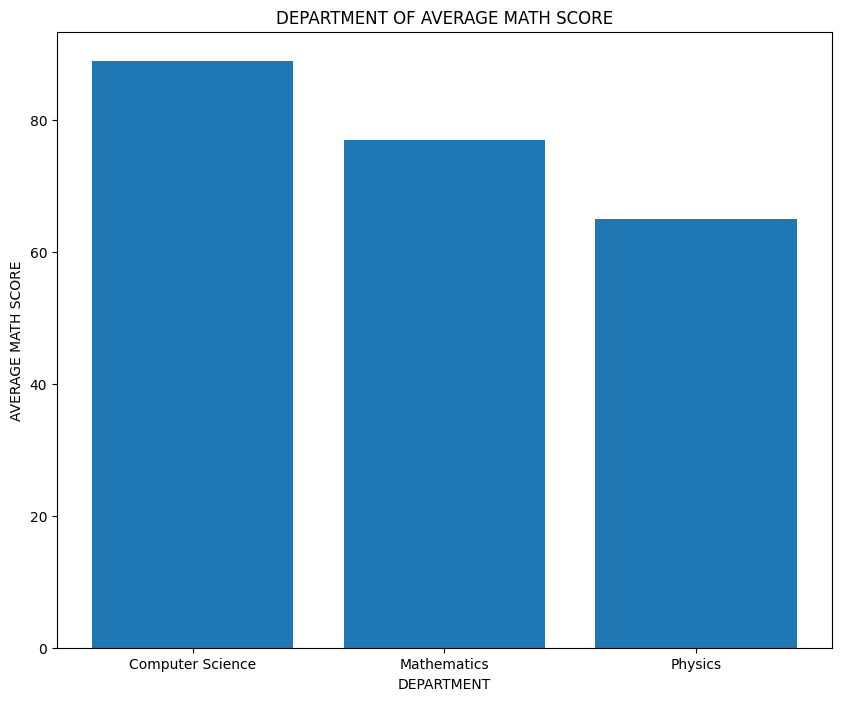

In [22]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('college.db')
chart_sql = """
SELECT department , ROUND(AVG(math_score)) AS  avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
data = pd.read_sql(chart_sql, conn)
conn.close()

print("=== Aggregated Data for Plotting ===")
print(data)

fig, ax = plt.subplots(figsize=(10,8 ))
plt.xlabel("DEPARTMENT")
plt.ylabel("AVERAGE MATH SCORE")
plt.title("DEPARTMENT OF AVERAGE MATH SCORE")
ax.bar(data['department'],data['avg_math'])
plt.show()

In [27]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

conn = sqlite3.connect('college.db')
cursor = conn.cursor()
chart_sql = """
SELECT department , AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department
ORDER BY avg_attendance DESC
"""
data = pd.read_sql(chart_sql,conn)
print("=== DataBase Connected Successfully ===")
print("")
print(data)
conn.close()

=== DataBase Connected Successfully ===

         department  avg_attendance
0  Computer Science       94.250000
1       Mathematics       86.000000
2           Physics       75.666667


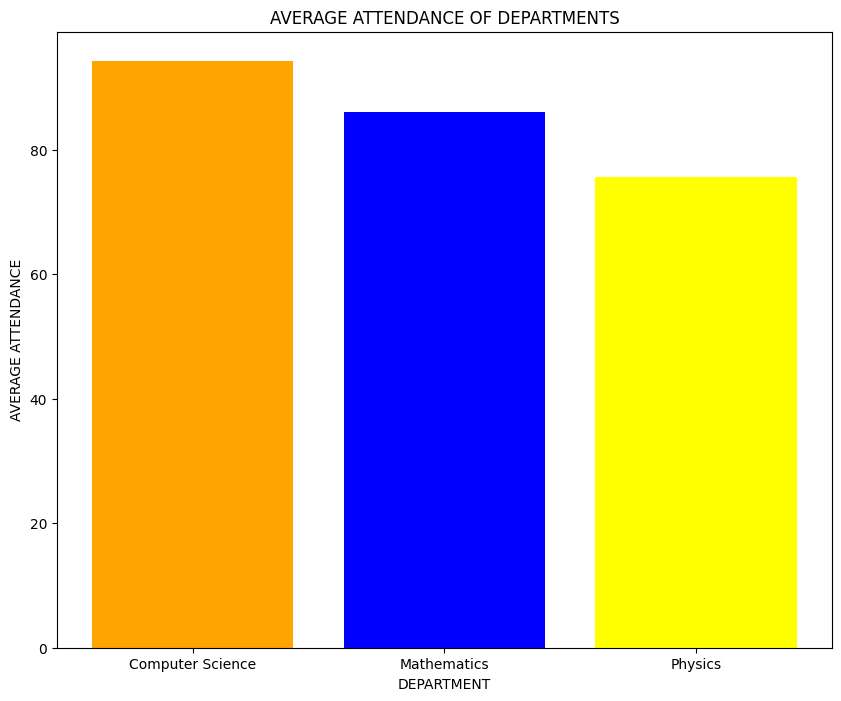

In [28]:
fig , ax = plt.subplots(figsize=(10,8))
plt.title("AVERAGE ATTENDANCE OF DEPARTMENTS")
plt.xlabel("DEPARTMENT")
plt.ylabel("AVERAGE ATTENDANCE")
plt.bar(data['department'],data['avg_attendance'], color = ['orange','blue','yellow','red'])
plt.show()

In [30]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('college.db')
cursor = conn.cursor()
chart_sql = """
SELECT department , ROUND(AVG(attendance_percentage)) AS  avg_attendance
FROM students
GROUP BY department
ORDER BY avg_attendance DESC
"""
data2 = pd.read_sql(chart_sql,conn)
conn.close()
print("=== DataBase Connected Successfully ===")
print("")
print(data2)
conn.close()

=== DataBase Connected Successfully ===

         department  avg_attendance
0  Computer Science            94.0
1       Mathematics            86.0
2           Physics            76.0


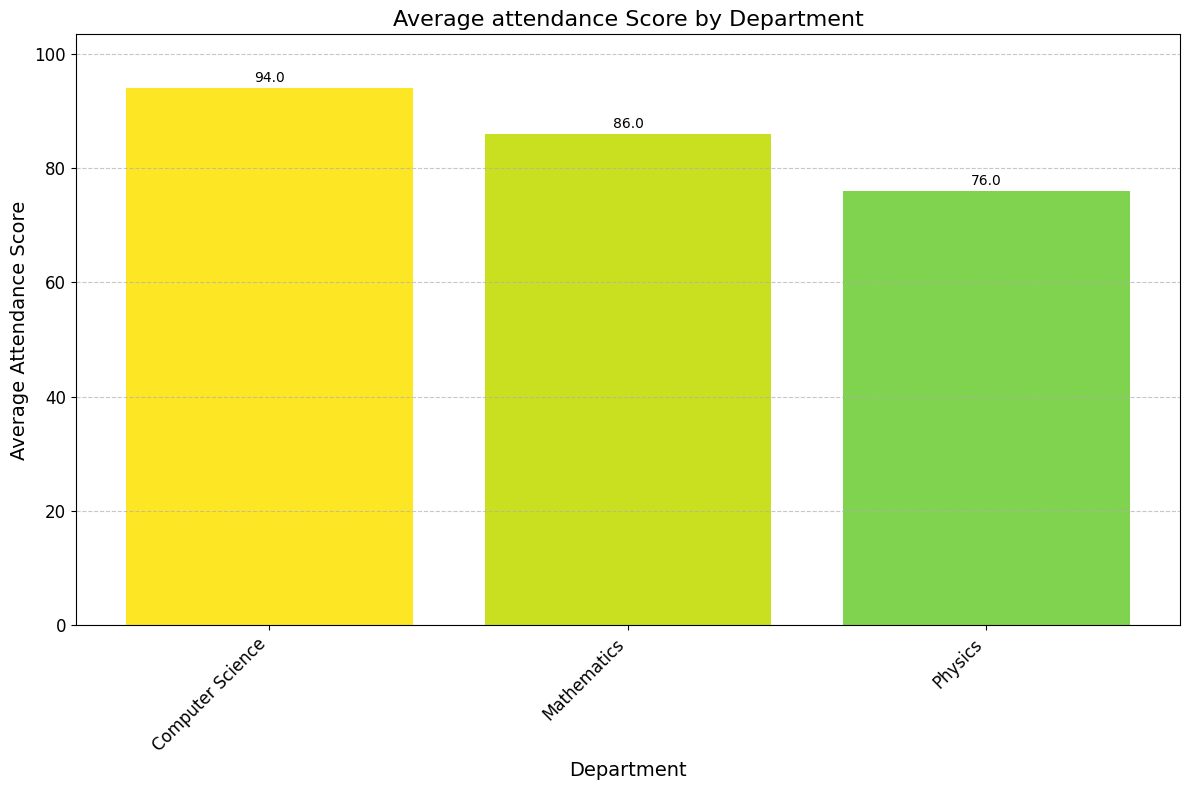

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(data2['avg_attendance'] / data2['avg_attendance'].max())

bars = ax.bar(data2['department'], data2['avg_attendance'], color=colors)

plt.xlabel("Department", fontsize=14)
plt.ylabel("Average Attendance Score", fontsize=14)
plt.title("Average attendance Score by Department", fontsize=16)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2), ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, data2['avg_attendance'].max() * 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

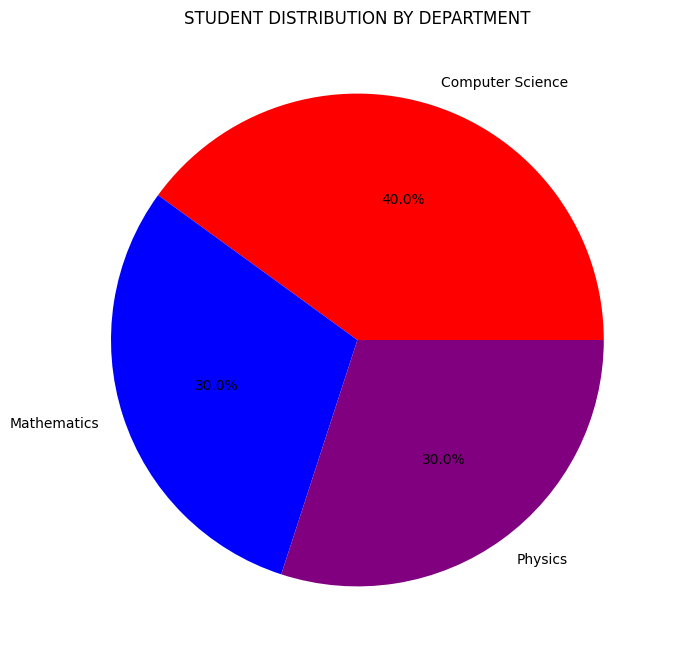

In [33]:
import sqlite3 as sql
import pandas as pd
import matplotlib.pyplot as plt

conn = sql.connect('college.db')
chart_sql = """
SELECT department, COUNT(student_id) AS student_count
FROM students
GROUP BY department
"""
department_data = pd.read_sql(chart_sql, conn)
conn.close()

# Count students department-wise
dept_count = department_data.set_index('department')['student_count']

# Create pie chart
fig, ax = plt.subplots(figsize=(8,8))

plt.pie(
    dept_count.values,
    labels=dept_count.index,
    autopct='%1.1f%%',
    colors=['red', 'blue', 'purple', 'orange']
)

plt.title("STUDENT DISTRIBUTION BY DEPARTMENT")

plt.show()

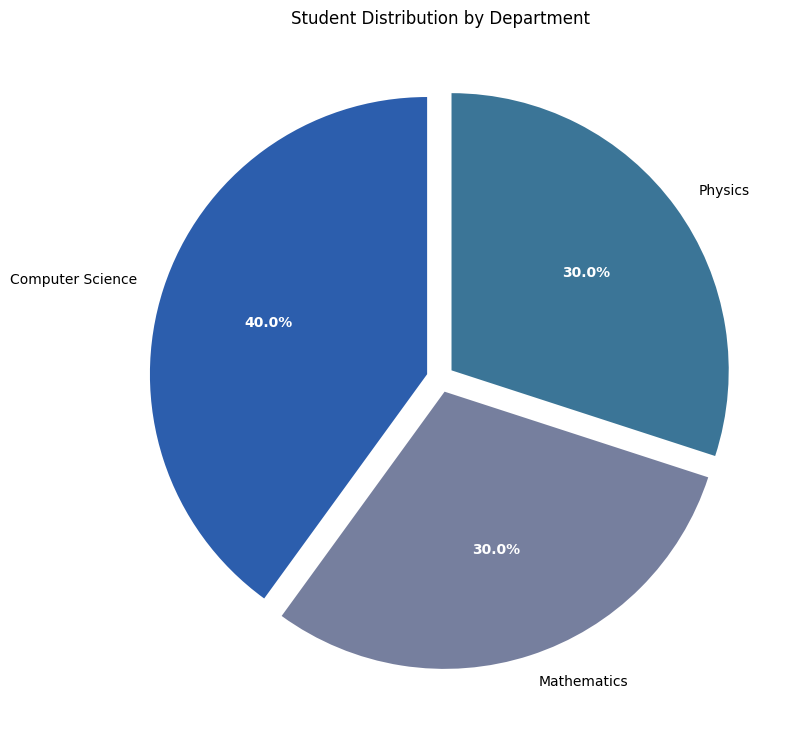

In [35]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('college.db')
cursor = conn.cursor()

chart2_sql = """
    SELECT department, COUNT(*) as student_count
    FROM students
    GROUP BY department
"""
cursor.execute(chart2_sql)
chart2_data = cursor.fetchall()
chart2_df = pd.DataFrame(chart2_data, columns=['Department', 'Student Count'])

conn.close()

custom_colors = ['#2C5EAD', '#767F9E', '#3B7597', '#121358']

explode = [0.05] * len(chart2_df)

plt.figure(figsize=(9, 9))
_, _, autotexts = plt.pie(
    chart2_df['Student Count'],
    labels=chart2_df['Department'],
    autopct='%1.1f%%',
    startangle=90,
    colors=custom_colors,
    explode=explode
)

for text in autotexts:
    text.set_color('white')
    text.set_weight('bold')

plt.title('Student Distribution by Department')
plt.show()

In [37]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

conn = sqlite3.connect('college.db')
cursor = conn.cursor()
chart_sql = """
SELECT department , ROUND(AVG(programming_score)) AS avg_programming_score
FROM students
GROUP BY department
ORDER BY avg_programming_score DESC
"""
data = pd.read_sql(chart_sql,conn)
print("=== DataBase Connected Successfully ===")
print("")
print(data)
conn.close()

=== DataBase Connected Successfully ===

         department  avg_programming_score
0  Computer Science                   88.0
1       Mathematics                   75.0
2           Physics                   67.0


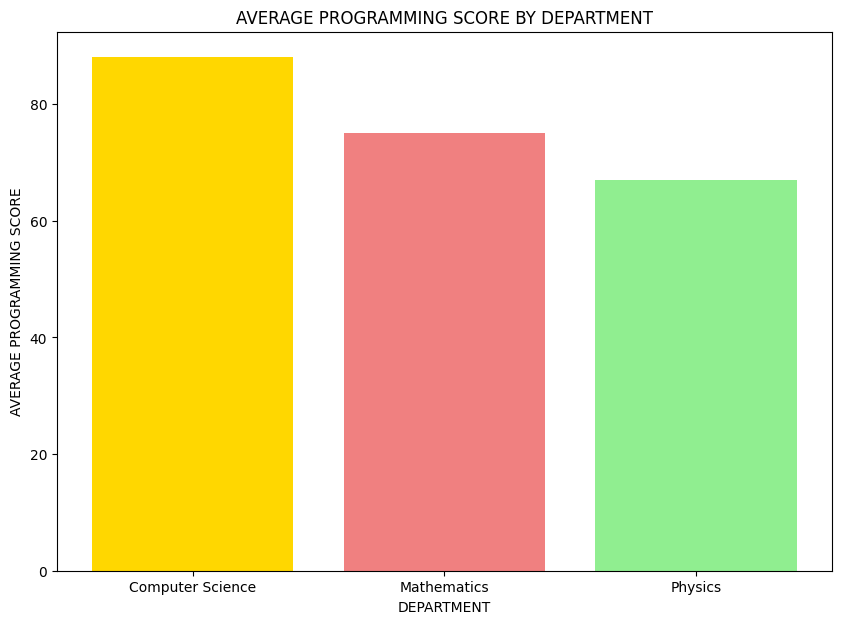

In [39]:
fig , ax = plt.subplots(figsize=(10,7))
plt.title("AVERAGE PROGRAMMING SCORE BY DEPARTMENT")
plt.xlabel("DEPARTMENT")
plt.ylabel("AVERAGE PROGRAMMING SCORE")
plt.bar(data['department'],data['avg_programming_score'], color = ['gold', 'lightcoral', 'lightgreen'])
plt.show()

In [40]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()
chart_sql = """
SELECT department , ROUND(AVG(programming_score)) AS  avg_prog
FROM students
GROUP BY department
ORDER BY avg_prog DESC
"""
data = run_query(chart_sql, "Average Programming Score by Department")
conn.close()

Average Programming Score by Department


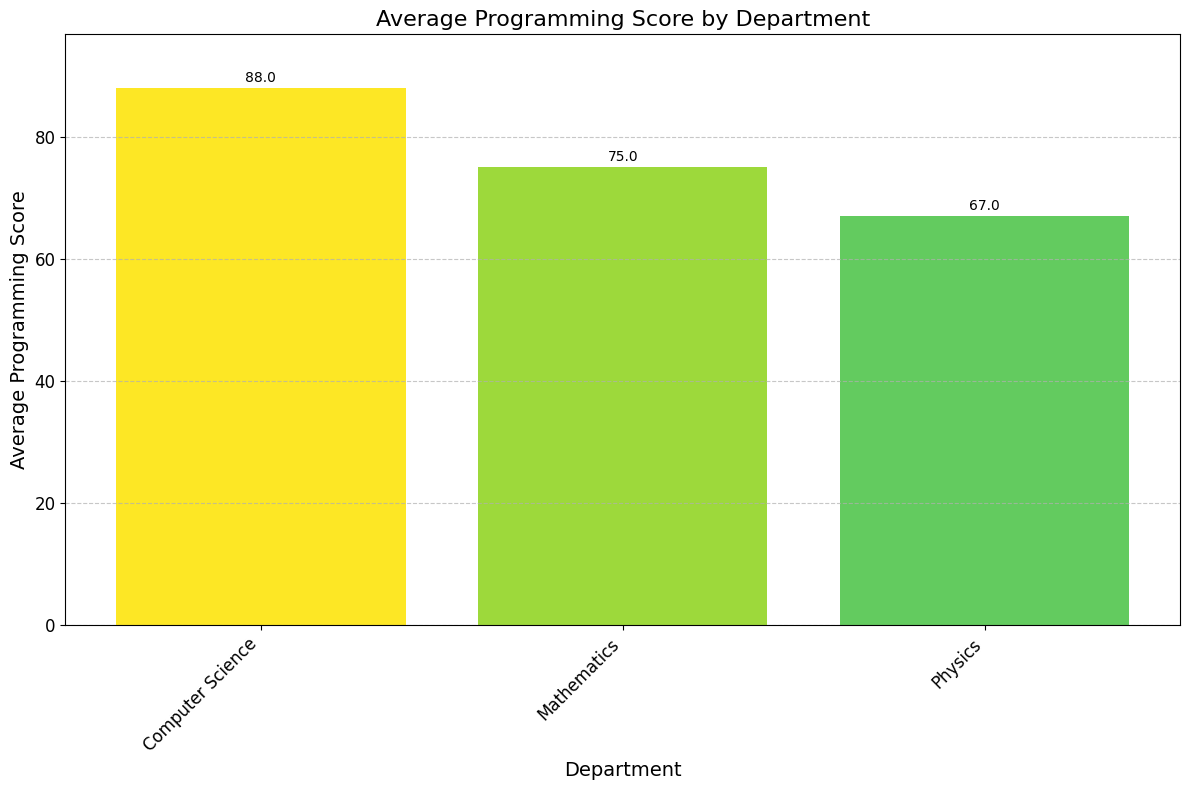

In [41]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(data['avg_prog'] / data['avg_prog'].max())

bars = ax.bar(data['department'], data['avg_prog'], color=colors)

plt.xlabel("Department", fontsize=14)
plt.ylabel("Average Programming Score", fontsize=14)
plt.title("Average Programming Score by Department", fontsize=16)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2), ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, data['avg_prog'].max() * 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()